<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/02_modelisation/blob/main/VGG16_Sareh_version1_block5unfreezed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 0 - Import required libraries

from pathlib import Path # Handle file paths more easily
from collections import Counter # Count how many times each element appears

import kagglehub # Download datasets directly from Kaggle

import numpy as np # Numerical computations
import pandas as pd # Work with tables and dataframes

import cv2 # Image processing with OpenCV

import matplotlib.pyplot as plt # Plot images and graphs
import seaborn as sns # Better visualizations

from sklearn.model_selection import train_test_split # Split dataset into train, validation and test sets
from sklearn.preprocessing import LabelEncoder # Encode class labels into numerical values
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,  precision_score, recall_score, f1_score # Evaluation metrics

import tensorflow as tf # Deep learning framework
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 1 - Download Kaggle dataset and define paths

path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# Download the COVID-19 radiography dataset from Kaggle

base_path = Path(path)
# Convert the returned path, which is a string, to a Path object

data_path = base_path / "COVID-19_Radiography_Dataset"
# Create the path pointing to the main dataset folder

print("Dataset downloaded to:", base_path)
# Show where the dataset has been downloaded

print("Main dataset folder:", data_path)
# Show the path to the dataset containing images and masks

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset downloaded to: /kaggle/input/covid19-radiography-database
Main dataset folder: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [ ]:
# Cell 2 - Inspect dataset structure

class_folders = sorted(
    [item.name for item in data_path.iterdir() if item.is_dir()]
)
# Get all folder names inside the main dataset directory
# and sort them alphabetically

print("Class folders found in the dataset:")
# Print a message before listing class folders

print(class_folders)
# Display all class folder names

Class folders found in the dataset:
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [ ]:
# Cell 3 - # Optional sanity check before building the final dataframe (Check dataset summary table and image/mask filename matching)

mismatch_report = []
# Create an empty list to store matching results for each class

for class_name in class_folders:
    # Loop through each class folder

    class_path = data_path / class_name
    # Build the full path of the current class

    images_path = class_path / "images"
    # Path to the images folder

    masks_path = class_path / "masks"
    # Path to the masks folder

    image_files = sorted([item.name for item in images_path.iterdir() if item.is_file()])
    # Get a sorted list of image filenames

    mask_files = sorted([item.name for item in masks_path.iterdir() if item.is_file()])
    # Get a sorted list of mask filenames

    filenames_match = image_files == mask_files
    # Check whether image and mask filenames match exactly

    mismatch_report.append({
        "class_name": class_name,
        "num_image_files": len(image_files),
        "num_mask_files": len(mask_files),
        "filenames_match": filenames_match
    })
    # Store the matching information for the current class

mismatch_df = pd.DataFrame(mismatch_report)
# Convert the matching report into a pandas DataFrame

mismatch_df
# Display the matching results

,class_name,num_image_files,num_mask_files,filenames_match
0,COVID,3616,3616,True
1,Lung_Opacity,6012,6012,True
2,Normal,10192,10192,True
3,Viral Pneumonia,1345,1345,True


In [ ]:
# Cell 4 - Build the main dataframe with image and mask paths

data_rows = []
# List to store all samples

for class_name in class_folders:
    # Loop through each class

    class_path = data_path / class_name
    # Build the full path of the current class

    images_path = class_path / "images"
    # Path to the images folder

    masks_path = class_path / "masks"
    # Path to the masks folder

    image_files = sorted([item.name for item in images_path.iterdir() if item.is_file()])
    # Get all image filenames

    for filename in image_files:
        # Loop through each image file

        image_path = images_path / filename
        # Build the full path of the image

        mask_path = masks_path / filename
        # Build the full path of the corresponding mask

        data_rows.append({
            "label": class_name,
            "image_path": str(image_path),
            "mask_path": str(mask_path)
        })
        # Store the class label, image path and mask path

main_df = pd.DataFrame(data_rows)
# Convert the list of samples into a pandas DataFrame

print("Dataset size:", main_df.shape)
# Display the total number of samples and columns

main_df.head()
# Display the first rows of the dataframe

Dataset size: (21165, 3)


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


Class distribution in the full dataset:
label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


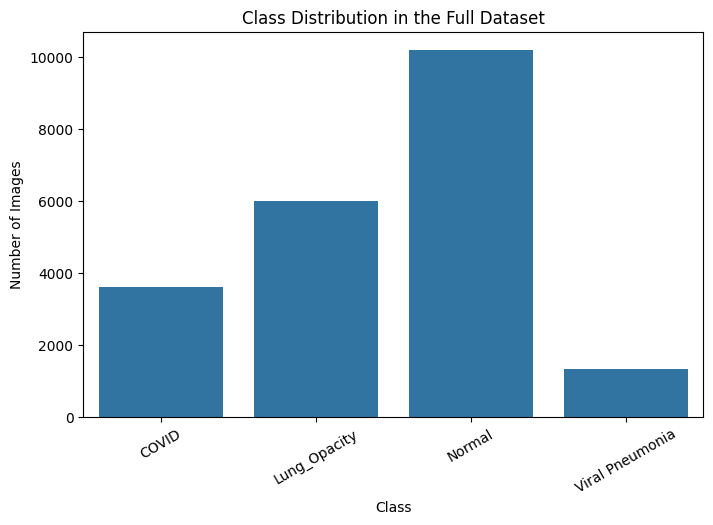

In [ ]:
# Cell 5 - Check class distribution

class_distribution = main_df["label"].value_counts()
# Count the number of images in each class

print("Class distribution in the full dataset:")
# Print a message before displaying class distribution

print(class_distribution)
# Display the class distribution

plt.figure(figsize=(8, 5))
# Create a new figure

sns.countplot(data=main_df, x="label")
# Plot the number of samples for each class

plt.title("Class Distribution in the Full Dataset")
# Add a title to the plot

plt.xlabel("Class")
# Add x-axis label

plt.ylabel("Number of Images")
# Add y-axis label

plt.xticks(rotation=30)
# Rotate x-axis labels for better readability

plt.show()
# Display the plot

In [ ]:
# Cell 6 - Create train / validation / test splits

train_df, temp_df = train_test_split(
    main_df,
    test_size=0.30,
    random_state=42,
    stratify=main_df["label"]
)
# Split the dataset into 70% training data and 30% temporary data

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)
# Split the temporary data into 15% validation data and 15% test data

train_df = train_df.reset_index(drop=True)
# Reset index of the training dataframe

val_df = val_df.reset_index(drop=True)
# Reset index of the validation dataframe

test_df = test_df.reset_index(drop=True)
# Reset index of the test dataframe

print("Training set size:", train_df.shape)
# Display the size of the training set

print("Validation set size:", val_df.shape)
# Display the size of the validation set

print("Test set size:", test_df.shape)
# Display the size of the test set

print("\nTraining class distribution:")
# Print a message before displaying training class distribution

print(train_df["label"].value_counts())
# Display class distribution in the training set

print("\nValidation class distribution:")
# Print a message before displaying validation class distribution

print(val_df["label"].value_counts())
# Display class distribution in the validation set

print("\nTest class distribution:")
# Print a message before displaying test class distribution

print(test_df["label"].value_counts())
# Display class distribution in the test set

print("\nTraining dataframe:")
# Print a message before displaying training dataframe

display(train_df.head())
# Display the first rows of the training dataframe

print("Validation dataframe:")
# Print a message before displaying validation dataframe

display(val_df.head())
# Display the first rows of the validation dataframe

print("Test dataframe:")
# Print a message before displaying test dataframe

display(test_df.head())
# Display the first rows of the test dataframe

Training set size: (14815, 3)
Validation set size: (3175, 3)
Test set size: (3175, 3)

Training class distribution:
label
Normal             7134
Lung_Opacity       4208
COVID              2531
Viral Pneumonia     942
Name: count, dtype: int64

Validation class distribution:
label
Normal             1529
Lung_Opacity        902
COVID               543
Viral Pneumonia     201
Name: count, dtype: int64

Test class distribution:
label
Normal             1529
Lung_Opacity        902
COVID               542
Viral Pneumonia     202
Name: count, dtype: int64

Training dataframe:


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


Validation dataframe:


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


Test dataframe:


,label,image_path,mask_path
0,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [ ]:
# Cell 7 - Save split dataframes for reproducibility

split_output_path = Path("dataset_splits")
# Define the output folder where split files will be saved

split_output_path.mkdir(exist_ok=True)
# Create the output folder if it does not already exist

train_df.to_csv(split_output_path / "train_df.csv", index=False)
# Save the training dataframe as a CSV file

val_df.to_csv(split_output_path / "val_df.csv", index=False)
# Save the validation dataframe as a CSV file

test_df.to_csv(split_output_path / "test_df.csv", index=False)
# Save the test dataframe as a CSV file

print("Split dataframes saved successfully.")
# Confirm that the files have been saved

print("Files saved in:", split_output_path)
# Display the output folder path

Split dataframes saved successfully.
Files saved in: dataset_splits


In [ ]:
# Cell 8 - Preprocess images and save them into train / val / test folders

IMG_SIZE = (224, 224)
# Define the image size required by VGG16

BATCH_SIZE = 32
# Define the batch size used during training

processed_base_path = Path("processed_dataset")
# Define the main output folder for processed images

for split_name, dataframe in zip(
    ["train", "val", "test"],
    [train_df, val_df, test_df]
):
    # Loop through each dataset split

    for _, row in dataframe.iterrows():
        # Loop through each row of the dataframe

        label = row["label"]
        # Get the class label

        image_path = row["image_path"]
        # Get the image path

        mask_path = row["mask_path"]
        # Get the mask path

        # Read the X-ray image in grayscale
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Read the corresponding lung mask
        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Resize the mask to match image dimensions
        mask_resized = cv2.resize(
            mask,
            (image.shape[1], image.shape[0])
        )

        # Convert resized mask back to binary
        _, mask_binary = cv2.threshold(
            mask_resized,
            127,
            255,
            cv2.THRESH_BINARY
        )

        # Apply the mask to keep only the lung region
        masked_image = cv2.bitwise_and(
            image,
            image,
            mask=mask_binary
        )

        # Resize image to VGG16 input size
        resized_image = cv2.resize(
            masked_image,
            IMG_SIZE
        )

        # Create output folder:
        # processed_dataset/train/COVID/
        output_folder = (
            processed_base_path /
            split_name /
            label
        )

        output_folder.mkdir(
            parents=True,
            exist_ok=True
        )
        # Create folders if they do not exist

        # Get the image filename only
        output_filename = Path(image_path).name

        # Final output path
        output_path = output_folder / output_filename

        # Save the processed image
        cv2.imwrite(
            str(output_path),
            resized_image
        )

print("Processed dataset created successfully.")
print("Processed images saved in:", processed_base_path)

Processed dataset created successfully.
Processed images saved in: processed_dataset


In [ ]:
# Cell 9 - Load train, validation and test datasets

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "processed_dataset/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "processed_dataset/val",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "processed_dataset/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

print("Datasets loaded successfully.")

Found 14815 files belonging to 4 classes.
Found 3175 files belonging to 4 classes.
Found 3175 files belonging to 4 classes.
Datasets loaded successfully.


In [ ]:
# Cell 10 - Define data augmentation for training images

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),
    # Randomly flip images horizontally

    tf.keras.layers.RandomRotation(0.03),
    # Apply small random rotations

    tf.keras.layers.RandomZoom(0.05),
    # Apply small random zoom variations

    tf.keras.layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    ),
    # Apply small random shifts

])

In [ ]:
# Cell 11 - Build the VGG16 transfer learning model

# Define model input
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

# Apply data augmentation
x = data_augmentation(inputs)

# Load pretrained VGG16
base_model = tf.keras.applications.VGG16(

    weights="imagenet",
    # Load pretrained ImageNet weights

    include_top=False,
    # Remove original VGG16 classifier

    input_tensor=x

)

# Freeze pretrained convolutional layers
base_model.trainable = False

# Extract feature maps from VGG16
x = base_model.output

# Convert feature maps into a feature vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# First dense layer
x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

# Second dense layer
x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

# Final classification layer
outputs = tf.keras.layers.Dense(
    4,
    activation="softmax"
)(x)

# Create final model
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

print("VGG16 model created successfully.")

VGG16 model created successfully.


In [ ]:
# Cell 12 - Compile the VGG16 model

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    # Define optimizer

    loss="categorical_crossentropy",
    # Loss function for multiclass classification

   metrics=[

    tf.keras.metrics.CategoricalAccuracy(
        name="accuracy"
    ),

    tf.keras.metrics.Precision(
        name="precision"
    ),

    tf.keras.metrics.Recall(
        name="recall"
    )

]

)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# Cell 13 - Define training callbacks

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",
    # Monitor validation loss

    patience=5,
    # Stop training if val_loss does not improve for 3 epochs

    restore_best_weights=True
    # Restore the best model weights

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",
    # Monitor validation loss

    factor=0.5,
    # Reduce learning rate by half

    patience=2,
    # Wait 2 epochs before reducing learning rate

    min_lr=1e-6
    # Minimum learning rate

)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_vgg16_model.keras",
    # File name for saving the best model

    monitor="val_loss",
    # Monitor validation loss

    save_best_only=True
    # Save only the best model

)

print("Callbacks created successfully.")

Callbacks created successfully.


In [ ]:
# Cell 14 - Compute class weights

from sklearn.utils.class_weight import compute_class_weight

# Get training labels
train_labels = train_df["label"]

# Get unique class names
class_names = np.array(
    sorted(train_labels.unique())
)

# Compute balanced class weights
class_weights = compute_class_weight(

    class_weight="balanced",

    classes=class_names,

    y=train_labels

)

# Convert to dictionary format
class_weight_dict = {

    i: weight
    for i, weight in enumerate(class_weights)

}

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: np.float64(1.4633544053733702), 1: np.float64(0.8801687262357415), 2: np.float64(0.5191687692738997), 3: np.float64(3.9317940552016983)}


In [ ]:
# Cell 15 - Train the VGG16 model

history = model.fit(

    train_dataset,
    # Training dataset

    validation_data=val_dataset,
    # Validation dataset

    epochs=30,
    # Maximum number of epochs

    class_weight=class_weight_dict,
    # Apply class weights to handle class imbalance

    callbacks=[

        early_stopping,
        reduce_lr,
        model_checkpoint

    ],
    # Training callbacks

    verbose=1
    # Display training progress

)

print("Training completed successfully.")

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 87s 167ms/step - accuracy: 0.4517 - loss: 1.5332 - precision: 0.4879 - recall: 0.3511 - val_accuracy: 0.6409 - val_loss: 0.8299 - val_precision: 0.7333 - val_recall: 0.5083 - learning_rate: 1.0000e-04
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 84s 181ms/step - accuracy: 0.6045 - loss: 0.8636 - precision: 0.6754 - recall: 0.4860 - val_accuracy: 0.6998 - val_loss: 0.7166 - val_precision: 0.7700 - val_recall: 0.6117 - learning_rate: 1.0000e-04
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 85s 183ms/step - accuracy: 0.6528 - loss: 0.7706 - precision: 0.7204 - recall: 0.5451 - val_accuracy: 0.7118 - val_loss: 0.6955 - val_precision: 0.7705 - val_recall: 0.6293 - learning_rate: 1.0000e-04
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 85s 184ms/step - accuracy: 0.6815 - loss: 0.7083 - precision: 0.7448 - recall: 0.5825 - val_accuracy: 0.7468 - val_loss: 0.6423 - val_precision: 0.7974 - val_recall: 0.6743 - learning_rate: 1.0000e-04
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━

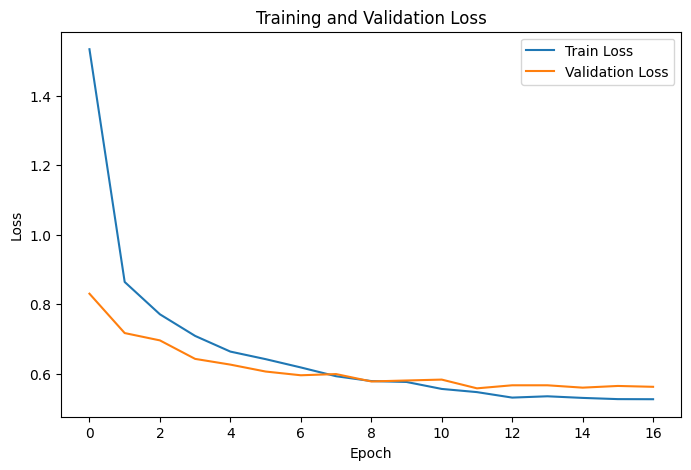

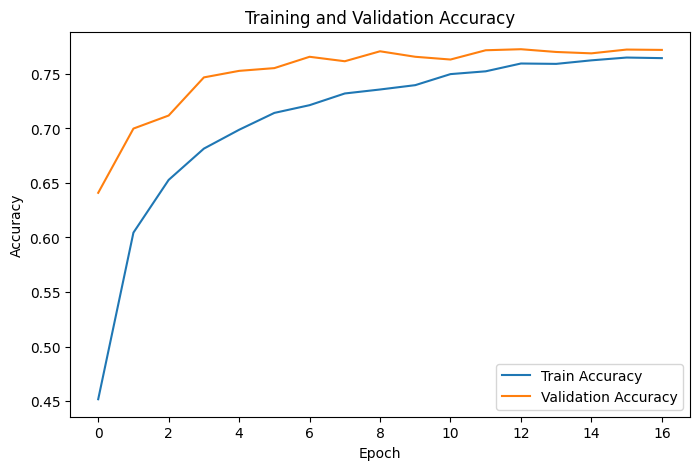

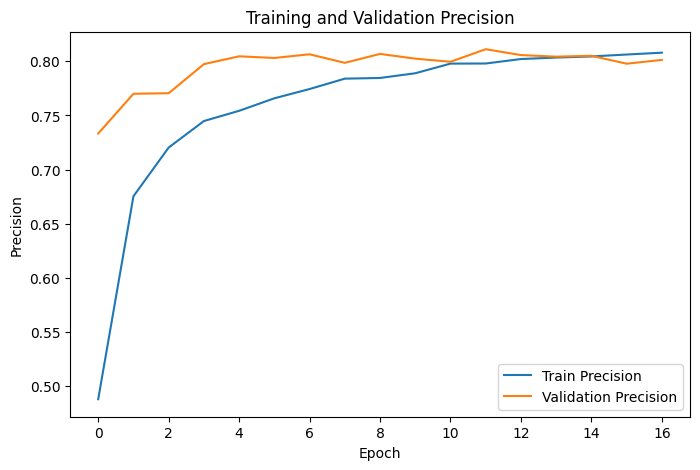

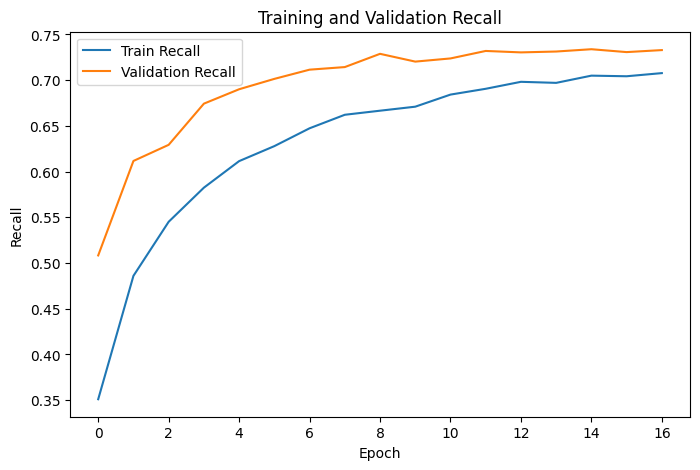

In [ ]:
# Cell 16 - Plot training curves

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()


# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()


# Plot training and validation precision
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["precision"],
    label="Train Precision"
)

plt.plot(
    history.history["val_precision"],
    label="Validation Precision"
)

plt.title("Training and Validation Precision")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.legend()

plt.show()


# Plot training and validation recall
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["recall"],
    label="Train Recall"
)

plt.plot(
    history.history["val_recall"],
    label="Validation Recall"
)

plt.title("Training and Validation Recall")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.legend()

plt.show()

In [ ]:
# Cell 17 - Fine-tune the last convolutional block of VGG16

# Unfreeze the base VGG16 model
base_model.trainable = True

# Freeze all layers except the last VGG16 block
for layer in base_model.layers[:-4]:

    layer.trainable = False

# Display trainable layers
for layer in base_model.layers:

    print(
        layer.name,
        "- Trainable:", layer.trainable
    )

# Recompile the model with a smaller learning rate
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )

    ]

)

print("Fine-tuning configuration completed.")

input_layer - Trainable: False
sequential - Trainable: False
block1_conv1 - Trainable: False
block1_conv2 - Trainable: False
block1_pool - Trainable: False
block2_conv1 - Trainable: False
block2_conv2 - Trainable: False
block2_pool - Trainable: False
block3_conv1 - Trainable: False
block3_conv2 - Trainable: False
block3_conv3 - Trainable: False
block3_pool - Trainable: False
block4_conv1 - Trainable: False
block4_conv2 - Trainable: False
block4_conv3 - Trainable: False
block4_pool - Trainable: False
block5_conv1 - Trainable: True
block5_conv2 - Trainable: True
block5_conv3 - Trainable: True
block5_pool - Trainable: True
Fine-tuning configuration completed.


In [ ]:
# Cell 18 - Fine-tune the VGG16 model

fine_tune_history = model.fit(

    train_dataset,
    # Training dataset

    validation_data=val_dataset,
    # Validation dataset

    epochs=20,
    # Fine-tuning epochs

    class_weight=class_weight_dict,
    # Handle class imbalance

    callbacks=[

        early_stopping,
        reduce_lr,
        model_checkpoint

    ],
    # Training callbacks

    verbose=1
    # Display training progress

)

print("Fine-tuning completed successfully.")

Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 91s 197ms/step - accuracy: 0.7619 - loss: 0.5262 - precision: 0.8037 - recall: 0.7105 - val_accuracy: 0.7956 - val_loss: 0.5143 - val_precision: 0.8208 - val_recall: 0.7776 - learning_rate: 1.0000e-05
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 97s 210ms/step - accuracy: 0.7892 - loss: 0.4715 - precision: 0.8237 - recall: 0.7447 - val_accuracy: 0.8145 - val_loss: 0.4866 - val_precision: 0.8428 - val_recall: 0.7871 - learning_rate: 1.0000e-05
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 97s 210ms/step - accuracy: 0.8061 - loss: 0.4410 - precision: 0.8383 - recall: 0.7609 - val_accuracy: 0.8258 - val_loss: 0.4534 - val_precision: 0.8662 - val_recall: 0.7830 - learning_rate: 1.0000e-05
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 97s 210ms/step - accuracy: 0.8164 - loss: 0.4196 - precision: 0.8485 - recall: 0.7747 - val_accuracy: 0.8334 - val_loss: 0.4401 - val_precision: 0.8627 - val_recall: 0.8016 - learning_rate: 1.0000e-05
Epoch 5/20
463/463 ━━━━━━━━━━━━━━━━━

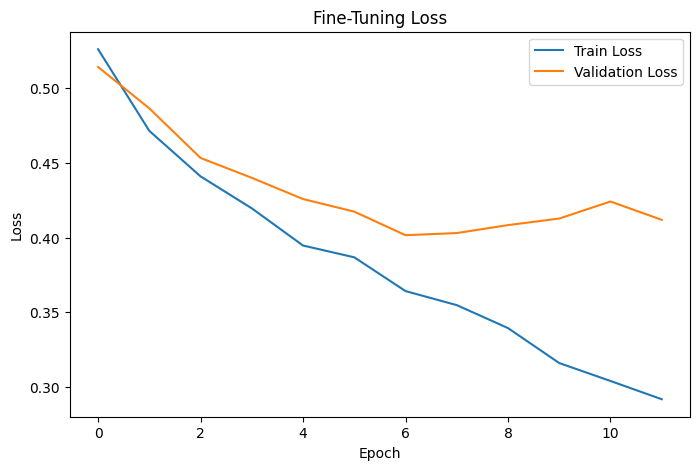

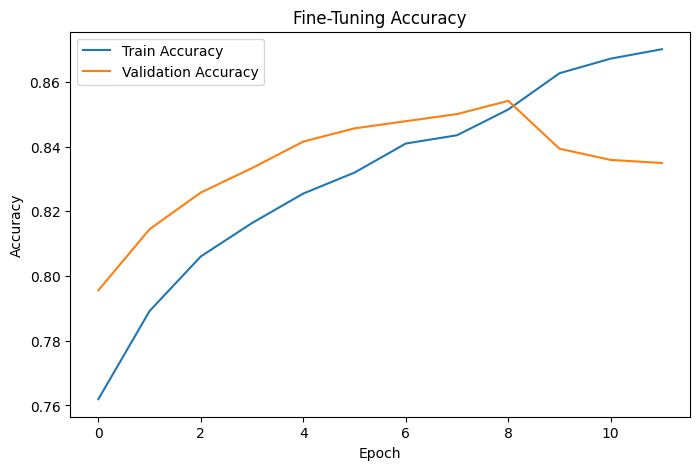

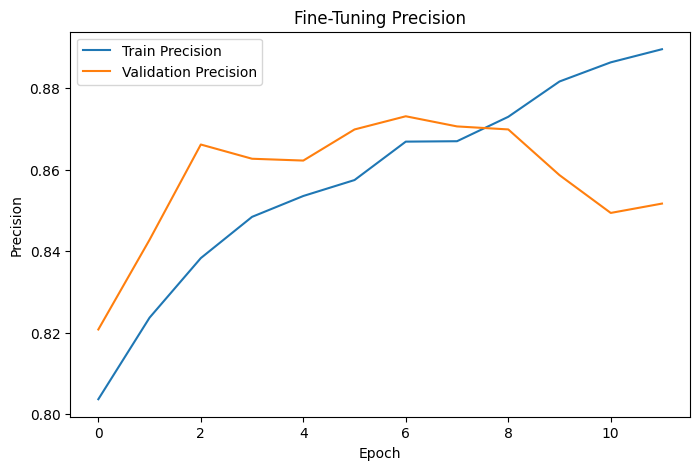

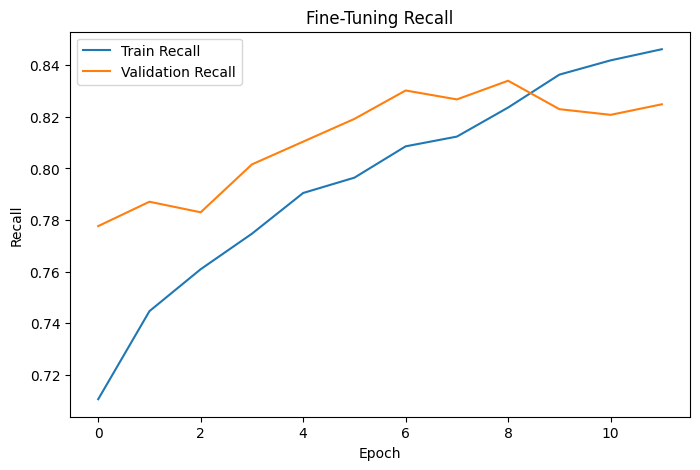

In [ ]:
# Cell 19 - Plot fine-tuning curves

# -------------------------------
# Plot Training and Validation Loss
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()


# -------------------------------
# Plot Training and Validation Accuracy
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


# -------------------------------
# Plot Training and Validation Precision
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["precision"],
    label="Train Precision"
)

plt.plot(
    fine_tune_history.history["val_precision"],
    label="Validation Precision"
)

plt.title("Fine-Tuning Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.legend()

plt.show()


# -------------------------------
# Plot Training and Validation Recall
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["recall"],
    label="Train Recall"
)

plt.plot(
    fine_tune_history.history["val_recall"],
    label="Validation Recall"
)

plt.title("Fine-Tuning Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.legend()

plt.show()

In [ ]:
# Cell 21 - Evaluate the best saved model

# Load the best saved checkpoint
best_model = tf.keras.models.load_model(
    "best_vgg16_model.keras"
)

print("Best model loaded successfully.")


# -------------------------------
# Evaluate on training dataset
# -------------------------------

train_results = best_model.evaluate(
    train_dataset,
    verbose=1
)

print("\n===== TRAIN RESULTS =====")

print(f"Train Loss      : {train_results[0]:.4f}")

print(f"Train Accuracy  : {train_results[1]:.4f}")

print(f"Train Precision : {train_results[2]:.4f}")

print(f"Train Recall    : {train_results[3]:.4f}")


# -------------------------------
# Evaluate on validation dataset
# -------------------------------

val_results = best_model.evaluate(
    val_dataset,
    verbose=1
)

print("\n===== VALIDATION RESULTS =====")

print(f"Validation Loss      : {val_results[0]:.4f}")

print(f"Validation Accuracy  : {val_results[1]:.4f}")

print(f"Validation Precision : {val_results[2]:.4f}")

print(f"Validation Recall    : {val_results[3]:.4f}")


# -------------------------------
# Evaluate on test dataset
# -------------------------------

test_results = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n===== TEST RESULTS =====")

print(f"Test Loss      : {test_results[0]:.4f}")

print(f"Test Accuracy  : {test_results[1]:.4f}")

print(f"Test Precision : {test_results[2]:.4f}")

print(f"Test Recall    : {test_results[3]:.4f}")

Best model loaded successfully.
463/463 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.8728 - loss: 0.3463 - precision: 0.8931 - recall: 0.8524

===== TRAIN RESULTS =====
Train Loss      : 0.3463
Train Accuracy  : 0.8728
Train Precision : 0.8931
Train Recall    : 0.8524
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.8479 - loss: 0.4016 - precision: 0.8731 - recall: 0.8302

===== VALIDATION RESULTS =====
Validation Loss      : 0.4016
Validation Accuracy  : 0.8479
Validation Precision : 0.8731
Validation Recall    : 0.8302
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.8545 - loss: 0.4120 - precision: 0.8711 - recall: 0.8321

===== TEST RESULTS =====
Test Loss      : 0.4120
Test Accuracy  : 0.8545
Test Precision : 0.8711
Test Recall    : 0.8321


100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step

===== CLASSIFICATION REPORT =====

                 precision    recall  f1-score   support

          COVID       0.73      0.78      0.75       542
   Lung_Opacity       0.91      0.78      0.84       902
         Normal       0.86      0.92      0.89      1529
Viral Pneumonia       0.98      0.86      0.92       202

       accuracy                           0.85      3175
      macro avg       0.87      0.83      0.85      3175
   weighted avg       0.86      0.85      0.85      3175



<Figure size 800x800 with 0 Axes>

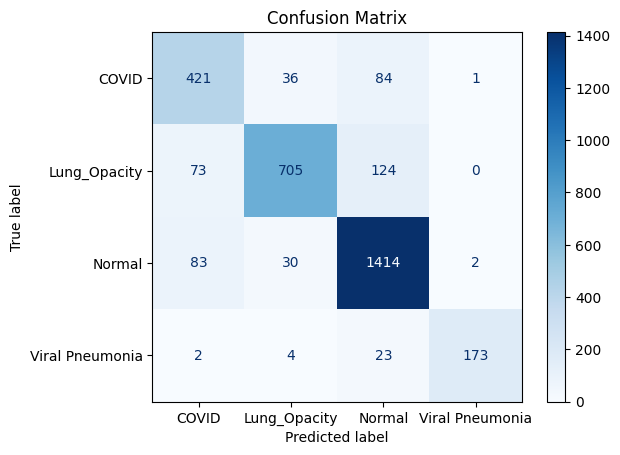

In [ ]:
# Cell 22 - Classification report and confusion matrix

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predict probabilities on test dataset
y_pred_probs = best_model.predict(
    test_dataset
)

# Convert probabilities to predicted class indices
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# Get true labels from test dataset
y_true = np.concatenate([

    np.argmax(y.numpy(), axis=1)

    for x, y in test_dataset

])

# Print classification report
print("\n===== CLASSIFICATION REPORT =====\n")

print(classification_report(

    y_true,
    y_pred,

    target_names=class_names

))

# Compute confusion matrix
cm = confusion_matrix(

    y_true,
    y_pred

)

# Plot confusion matrix
plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,
    display_labels=class_names

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()